<a href="https://colab.research.google.com/github/ankitag86/springboard/blob/main/Hyperparameter_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Extracting a Logistic Regression parameter

from sklearn.linear_model import LogisticRegression
import pandas as pd

# Create a list of original variable names from the training DataFrame
original_variables = X_train.columns

# Extract the coefficients of the logistic regression estimator
model_coefficients = log_reg_clf.coef_[0]

# Create a dataframe of the variables and coefficients & print it out
coefficient_df = pd.DataFrame({"Variable" : original_variables, "Coefficient": model_coefficients})
print(coefficient_df)

# Print out the top 3 positive variables
top_three_df = coefficient_df.sort_values(by="Coefficient", axis=0, ascending=False)[0:3]
print(top_three_df)

    Variable   Coefficient
0     LIMIT_BAL -3.146007e-06
1           AGE -1.667351e-02
2         PAY_0  1.180600e-03
3         PAY_2  8.930544e-04
4         PAY_3  7.965670e-04
5         PAY_4  7.851508e-04
6         PAY_5  7.263725e-04
7         PAY_6  6.704895e-04
8     BILL_AMT1 -6.855808e-06
9     BILL_AMT2  4.410500e-06
10    BILL_AMT3  2.179079e-06
11    BILL_AMT4  5.482805e-07
12    BILL_AMT5  2.105253e-06
13    BILL_AMT6  2.514244e-06
14     PAY_AMT1 -3.239663e-05
15     PAY_AMT2 -2.570219e-05
16     PAY_AMT3 -6.103578e-06
17     PAY_AMT4 -7.670497e-06
18     PAY_AMT5 -5.088686e-06
19     PAY_AMT6 -2.729188e-06
20        SEX_2 -3.806425e-04
21  EDUCATION_1 -1.122823e-04
22  EDUCATION_2 -2.846602e-04
23  EDUCATION_3 -1.137210e-04
24  EDUCATION_4 -7.239638e-06
25  EDUCATION_5 -2.047148e-05
26  EDUCATION_6 -1.976180e-06
27   MARRIAGE_1 -1.068800e-04
28   MARRIAGE_2 -4.193479e-04
29   MARRIAGE_3 -1.006513e-05
  Variable  Coefficient
2    PAY_0     0.001181
3    PAY_2     0.000893
4    PAY_3     0.000797

In [ ]:
#Extracting a Random Forest parameter

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_graphviz
import os
import pydot

rf_clf = RandomForestClassifier(max_depth=4, criterion='gini', n_estimators=10);
rf_clf.fit(X_train, y_train)

# Extract the 7th (index 6) tree from the random forest
chosen_tree = rf_clf.estimators_[6]

# Visualize the graph using the provided image
imgplot = plt.imshow(tree_viz_image)
plt.show()

# Extract the parameters and level of the top (index 0) node
split_column = chosen_tree.tree_.feature[0]
split_column_name = X_train.columns[split_column]
split_value = chosen_tree.tree_.threshold[0]

# Print out the feature and level
print('This node split on feature {}, at a value of {}'.format(split_column_name, split_value))

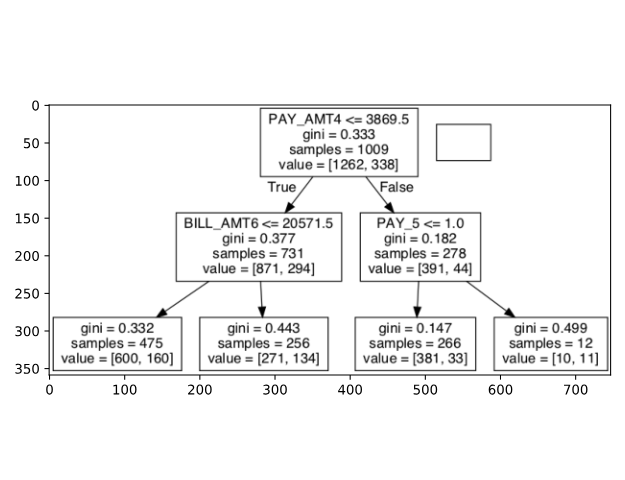

In [ ]:
#Exploring Random Forest Hyperparameters

from sklearn.metrics import confusion_matrix, accuracy_score

rf_clf_old = RandomForestClassifier(min_samples_leaf=1, min_samples_split=2,
                                    n_estimators=5, oob_score=False, random_state=42)

rf_clf_old.fit(X_train, y_train)
rf_old_predictions = rf_clf_old.predict(X_test)

# Print out the old estimator, notice which hyperparameter is badly set
print(rf_clf_old)

# Get confusion matrix & accuracy for the old rf_model
print('Confusion Matrix: \n\n {} \n Accuracy Score: \n\n {}'.format(
    confusion_matrix(y_test, rf_old_predictions),
    accuracy_score(y_test, rf_old_predictions)
))


RandomForestClassifier(n_estimators=5, random_state=42)
Confusion Matrix:

 [[6336  667]
 [1249  748]]
 Accuracy Score:

 0.7871111111111111

In [ ]:
rf_clf_new = RandomForestClassifier(n_estimators=500)

# Fit this to the data and obtain predictions
rf_new_predictions = rf_clf_new.fit(X_train, y_train).predict(X_test)

# Assess the new model (using new predictions!)
print('Confusion Matrix: \n\n', confusion_matrix(y_test, rf_new_predictions))
print('Accuracy Score: \n\n', accuracy_score(y_test, rf_new_predictions))

Confusion Matrix:

 [[6638  365]
 [1235  762]]
Accuracy Score:

 0.8222222222222222

In [ ]:
# Hyperparameters of KNN

# Build a knn estimator for each value of n_neighbours
knn_5 = KNeighborsClassifier(n_neighbors=5)
knn_10 = KNeighborsClassifier(n_neighbors=10)
knn_20 = KNeighborsClassifier(n_neighbors=20)

# Fit each to the training data & produce predictions
knn_5_predictions = knn_5.fit(X_train, y_train).predict(X_test)
knn_10_predictions = knn_10.fit(X_train, y_train).predict(X_test)
knn_20_predictions = knn_20.fit(X_train, y_train).predict(X_test)

# Get an accuracy score for each of the models
knn_5_accuracy = accuracy_score(y_test, knn_5_predictions)
knn_10_accuracy = accuracy_score(y_test, knn_10_predictions)
knn_20_accuracy = accuracy_score(y_test, knn_20_predictions)
print("The accuracy of 5, 10, 20 neighbours was {}, {}, {}".format(knn_5_accuracy, knn_10_accuracy, knn_20_accuracy))

The accuracy of 5, 10, 20 neighbors was 0.755, 0.7764444444444445, 0.7804444444444445

In [ ]:
#Automating Hyperparameter Choice

#Possible learning rates to try include 0.001, 0.01, 0.05, 0.1, 0.2 and 0.5

from sklearn.ensemble import GradientBoostingClassifier

# Set the learning rates & results storage
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5]
results_list = []

# Create the for loop to evaluate model predictions for each learning rate
for learning_rate in learning_rates:
    model = GradientBoostingClassifier(learning_rate=learning_rate)
    predictions = model.fit(X_train, y_train).predict(X_test)

    # Save the learning rate and accuracy score
    results_list.append([learning_rate, accuracy_score(y_test, predictions)])

# Gather everything into a DataFrame
results_df = pd.DataFrame(results_list, columns=['learning_rate', 'accuracy'])
print(results_df)

   learning_rate  accuracy
0          0.001  0.778111
1          0.010  0.823000
2          0.050  0.826000
3          0.100  0.825556
4          0.200  0.823333
5          0.500  0.818778






In [ ]:
#Building Learning Curves

# Set the learning rates & accuracies list.Create a list of 30 learning rates evenly spread between 0.01 and 2.
learn_rates = np.linspace(0.01, 2, num=30)
accuracies = []

# Create the for loop
for learn_rate in learn_rates:
  	# Create the model, predictions & save the accuracies as before
    model = GradientBoostingClassifier(learning_rate=learn_rate)
    predictions = model.fit(X_train, y_train).predict(X_test)
    accuracies.append(accuracy_score(y_test, predictions))

# Plot results
plt.plot(learn_rates, accuracies)
plt.gca().set(xlabel='learning_rate', ylabel='Accuracy', title='Accuracy for different learning_rates')
plt.show()

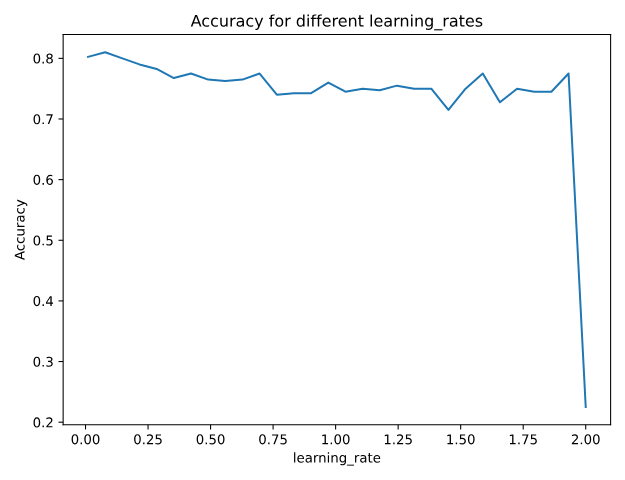

GRID SEARCH

Build Grid Search functions

In data science it is a great idea to try building algorithms, models and processes 'from scratch' so you can really understand what is happening at a deeper level. Of course there are great packages and libraries for this work (and we will get to that very soon!) but building from scratch will give you a great edge in your data science work.

In this exercise, you will create a function to take in 2 hyperparameters, build models and return results. You will use this function in a future exercise.

You will have available the X_train, X_test, y_train and y_test datasets available.

Instructions
100 XP
Build a function that takes two parameters called learning_rate and max_depth for the learning rate and maximum depth.
Add capability in the function to build a GBM model and fit it to the data with the input hyperparameters.
Have the function return the results of that model and the chosen hyperparameters (learning_rate and max_depth).

In [ ]:
#Build Grid Search functions

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Create the function
def gbm_grid_search(learning_rate, max_depth):
	# Create the model
    model = GradientBoostingClassifier(learning_rate=learning_rate, max_depth=max_depth)

    # Use the model to make predictions
    predictions = model.fit(X_train, y_train).predict(X_test)

    # Return the hyperparameters and score
    return([learning_rate, max_depth, accuracy_score(y_test, predictions)])

Iteratively tune multiple hyperparameters
In this exercise, you will build on the function you previously created to take in 2 hyperparameters, build a model and return the results. You will now use that to loop through some values and then extend this function and loop with another hyperparameter.

The function gbm_grid_search(learn_rate, max_depth) is available in this exercise.

If you need to remind yourself of the function you can run the function print_func() that has been created for you

Write a for-loop to test the values (0.01, 0.1, 0.5) for the learning_rate and (2, 4, 6) for the max_depth using the function you created gbm_grid_search and print the results.

In [ ]:
#Iteratively tune multiple hyperparameters
# Create the relevant lists
results_list = []
learn_rate_list = [0.01, 0.1, 0.5]
max_depth_list = [2, 4, 6]

# Create the for loop
for learn_rate in learn_rate_list:
    for max_depth in max_depth_list:
        results_list.append(gbm_grid_search(learn_rate,max_depth))

# Print the results
print(results_list)

 [[0.01, 2, 0.78], [0.01, 4, 0.78], [0.01, 6, 0.76], [0.1, 2, 0.74], [0.1, 4, 0.76], [0.1, 6, 0.75], [0.5, 2, 0.73], [0.5, 4, 0.74], [0.5, 6, 0.74]]

GridSearchCV with Scikit Learn
The GridSearchCV module from Scikit Learn provides many useful features to assist with efficiently undertaking a grid search. You will now put your learning into practice by creating a GridSearchCV object with certain parameters.

The desired options are:

A Random Forest Estimator, with the split criterion as 'entropy'
5-fold cross validation
The hyperparameters max_depth (2, 4, 8, 15) and max_features ('auto' vs 'sqrt')
Use roc_auc to score the models
Use 4 cores for processing in parallel
Ensure you refit the best model and return training scores
You will have available X_train, X_test, y_train & y_test datasets.

Instructions:

Create a Random Forest estimator as specified in the context above.
Create a parameter grid as specified in the context above.
Create a GridSearchCV object as outlined in the context above, using the two elements created in the previous two instructions.

In [ ]:
# Create a Random Forest Classifier with specified criterion
rf_class = RandomForestClassifier(criterion ='entropy')

# Create the parameter grid
param_grid = {'max_depth': [2, 4, 8, 15], 'max_features': ['auto','sqrt']}

# Create a GridSearchCV object
grid_rf_class = GridSearchCV(
    estimator=rf_class,
    param_grid=param_grid,
    scoring='roc_auc',
    n_jobs=4,
    cv=5,
    refit=True, return_train_score=True)
print(grid_rf_class)

<script.py> output:
    GridSearchCV(cv=5, estimator=RandomForestClassifier(criterion='entropy'),
                 n_jobs=4,
                 param_grid={'max_depth': [2, 4, 8, 15],
                             'max_features': ['auto', 'sqrt']},
                 return_train_score=True, scoring='roc_auc')

RANDOM SEARCH

Randomly Sample Hyperparameters
To undertake a random search, we firstly need to undertake a random sampling of our hyperparameter space.

In this exercise, you will firstly create some lists of hyperparameters that can be zipped up to a list of lists. Then you will randomly sample hyperparameter combinations in preparation for running a random search.

You will use just the hyperparameters learning_rate and min_samples_leaf of the GBM algorithm to keep the example illustrative and not overly complicated.

Instructions
Create a list of 200 values for the learning_rate hyperparameter between 0.01 and 1.5 and assign to the list learn_rate_list.
Create a list of values between 10 and 40 inclusive for the hyperparameter min_samples_leaf and assign to the list min_samples_list.
Combine these lists into a list of lists to sample from.
Randomly sample 250 models from these hyperparameter combinations and print the result.

In [ ]:
from itertools import product

# Create a list of values for the learning_rate hyperparameter
learn_rate_list = list(np.linspace(0.01, 1.5, 200))

# Create a list of values for the min_samples_leaf hyperparameter
min_samples_list = list(range(10,41))

# Combination list
combinations_list = [list(x) for x in product(learn_rate_list, min_samples_list)]

# Sample hyperparameter combinations for a random search.
random_combinations_index = np.random.choice(range(0, len(combinations_list)), 250, replace=False)
combinations_random_chosen = [combinations_list[x] for x in random_combinations_index]

# Print the result
print(combinations_random_chosen)

<script.py> output:
    [[1.305326633165829, 14], [0.6015075376884422, 24], [0.6089949748743718, 35], [1.3128140703517588, 33], [0.3244723618090452, 23], [0.07738693467336683, 27], [0.2421105527638191, 18], [1.1855276381909547, 24], [0.17472361809045225, 11], [0.7662311557788944, 12], [1.0657286432160804, 39], [0.7287939698492463, 22], [1.2604020100502513, 40], [1.0881909547738693, 12], [1.2079899497487436, 39], [1.4475879396984925, 15], [1.327788944723618, 16], [0.7587437185929649, 37], [0.46673366834170854, 10], [0.2720603015075377, 22], [1.2079899497487436, 12], [1.095678391959799, 27], [0.5790452261306532, 31], [0.18969849246231157, 22], [0.17472361809045225, 40], [1.2604020100502513, 39], [0.33195979899497485, 39], [0.05492462311557789, 32], [0.6314572864321608, 40], [0.9758793969849247, 14], [0.7886934673366834, 40], [1.200502512562814, 15], [0.4592462311557789, 22], [0.8635678391959799, 16], [0.7512562814070352, 37], [0.039949748743718594, 18], [0.6838693467336683, 38], [1.1480904522613065, 29], [0.42180904522613066, 31], [0.9010050251256281, 31], [0.26457286432160804, 29], [0.945929648241206, 12], [0.46673366834170854, 16], [1.1630653266331659, 18], [0.7587437185929649, 13], [0.6464321608040201, 16], [0.7812060301507537, 14], [1.0282914572864321, 35], [0.6838693467336683, 12], [0.19718592964824122, 22], [0.12231155778894472, 10], [1.4850251256281406, 15], [0.6988442211055276, 31], [0.4966834170854271, 40], [0.2945226130653266, 31], [1.222964824120603, 28], [1.0582412060301507, 25], [0.7362814070351759, 30], [1.1930150753768844, 17], [0.945929648241206, 21], [1.095678391959799, 35], [0.414321608040201, 39], [1.1555778894472362, 34], [0.7812060301507537, 24], [1.3352763819095477, 29], [0.9309547738693467, 10], [1.0657286432160804, 20], [1.07321608040201, 39], [1.3128140703517588, 21], [1.222964824120603, 18], [0.09984924623115578, 16], [0.36939698492462314, 35], [1.1555778894472362, 33], [0.17472361809045225, 24], [0.024974874371859294, 28], [1.178040201005025, 24], [0.6314572864321608, 29], [0.8261306532663316, 24], [1.4101507537688442, 30], [0.7737185929648241, 29], [1.3951758793969848, 15], [1.222964824120603, 15], [0.7362814070351759, 17], [1.2379396984924622, 24], [0.38437185929648243, 19], [1.07321608040201, 11], [1.4326130653266331, 31], [0.7437688442211056, 17], [1.2154773869346733, 14], [0.6015075376884422, 12], [0.5565829145728644, 19], [1.4401005025125628, 20], [1.222964824120603, 11], [1.2828643216080402, 20], [1.3352763819095477, 18], [1.200502512562814, 24], [1.29035175879397, 16], [0.9010050251256281, 36], [0.9010050251256281, 26], [1.4176381909547737, 17], [1.4326130653266331, 30], [0.3993467336683417, 13], [0.12979899497487438, 20], [1.0881909547738693, 17], [0.024974874371859294, 27], [0.3244723618090452, 10], [0.48170854271356783, 20], [0.6164824120603015, 22], [0.9384422110552764, 28], [0.9833668341708542, 36], [1.1406030150753768, 22], [1.2604020100502513, 20], [0.15974874371859296, 15], [1.2379396984924622, 29], [1.2154773869346733, 28], [0.34693467336683415, 34], [0.6539195979899497, 28], [0.06241206030150754, 26], [1.4925125628140703, 31], [1.4700502512562814, 19], [0.2720603015075377, 33], [0.40683417085427137, 39], [0.2945226130653266, 15], [0.8336180904522613, 13], [0.7886934673366834, 12], [1.3128140703517588, 28], [1.1630653266331659, 22], [0.9084924623115578, 21], [1.3577386934673366, 20], [0.6314572864321608, 15], [0.2421105527638191, 13], [1.2379396984924622, 10], [1.07321608040201, 13], [1.4401005025125628, 31], [0.3544221105527638, 27], [0.2945226130653266, 18], [0.7362814070351759, 13], [0.04743718592964824, 22], [0.8935175879396985, 16], [1.1181407035175879, 31], [1.200502512562814, 31], [1.3352763819095477, 31], [0.8860301507537688, 40], [0.12231155778894472, 17], [0.12231155778894472, 14], [1.1406030150753768, 20], [0.3993467336683417, 21], [0.6164824120603015, 25], [0.7063316582914573, 17], [0.03246231155778895, 10], [0.01, 33], [1.1181407035175879, 11], [0.7587437185929649, 15], [1.1630653266331659, 12], [0.7587437185929649, 23], [0.691356783919598, 35], [1.095678391959799, 25], [0.2421105527638191, 26], [1.0357788944723618, 23], [0.26457286432160804, 12], [1.2753768844221105, 34], [0.6239698492462311, 27], [0.414321608040201, 35], [1.4775376884422111, 32], [0.09984924623115578, 39], [0.5116582914572865, 36], [0.6015075376884422, 14], [0.36939698492462314, 31], [0.3394472361809045, 39], [1.5, 33], [0.06989949748743718, 25], [0.5116582914572865, 10], [1.0058291457286432, 15], [0.5640703517587939, 15], [0.09984924623115578, 31], [1.4176381909547737, 27], [0.6239698492462311, 40], [1.1630653266331659, 29], [1.2379396984924622, 23], [1.2304522613065327, 18], [1.327788944723618, 13], [0.6539195979899497, 32], [0.3094974874371859, 14], [1.178040201005025, 11], [0.7138190954773869, 28], [1.2978391959798994, 37], [0.09236180904522612, 20], [1.178040201005025, 30], [0.4592462311557789, 38], [1.4925125628140703, 23], [1.3951758793969848, 30], [0.3993467336683417, 14], [1.1555778894472362, 36], [1.0807035175879396, 14], [0.13728643216080402, 27], [0.6015075376884422, 11], [0.414321608040201, 31], [1.2304522613065327, 31], [1.4026633165829145, 37], [1.1555778894472362, 39], [0.287035175879397, 21], [1.1555778894472362, 20], [0.8485929648241206, 29], [0.2570854271356784, 19], [1.5, 39], [0.8111557788944723, 29], [1.07321608040201, 19], [0.6164824120603015, 21], [0.8036683417085427, 14], [0.15226130653266332, 20], [0.1822110552763819, 39], [0.5565829145728644, 38], [0.2121608040201005, 38], [0.09236180904522612, 15], [0.7587437185929649, 19], [1.013316582914573, 11], [1.3876884422110551, 22], [0.11482412060301507, 13], [1.3951758793969848, 22], [0.017487437185929648, 16], [0.06241206030150754, 23], [1.4026633165829145, 34], [1.3352763819095477, 23], [1.1705527638190953, 33], [0.2570854271356784, 26], [0.45175879396984925, 25], [0.5191457286432161, 20], [0.5416080402010051, 37], [0.42180904522613066, 37], [0.6838693467336683, 29], [0.7213065326633166, 10], [0.7437688442211056, 37], [0.04743718592964824, 11], [0.05492462311557789, 22], [0.01, 24], [1.3876884422110551, 34], [1.4925125628140703, 24], [0.36939698492462314, 20], [0.18969849246231157, 30], [1.4850251256281406, 35], [1.2753768844221105, 10], [1.2604020100502513, 28], [0.945929648241206, 39], [0.7287939698492463, 30], [0.8785427135678392, 13], [1.4101507537688442, 25], [0.7662311557788944, 14], [0.5116582914572865, 31], [1.1555778894472362, 27], [0.30201005025125627, 21]]


Randomly Search with Random Forest
To solidify your knowledge of random sampling, let's try a similar exercise but using different hyperparameters and a different algorithm.

As before, create some lists of hyperparameters that can be zipped up to a list of lists. You will use the hyperparameters criterion, max_depth and max_features of the random forest algorithm. Then you will randomly sample hyperparameter combinations in preparation for running a random search.

You will use a slightly different package for sampling in this task, random.sample().

Instructions
Create lists of the values 'gini' and 'entropy' for criterion & "auto", "sqrt", "log2", None for max_features.
Create a list of values between 3 and 55 inclusive for the hyperparameter max_depth and assign to the list max_depth_list. Remember that range(N,M) will create a list from N to M-1.
Combine these lists into a list of lists to sample from using product().
Randomly sample 150 models from the combined list and print the resul

In [ ]:
# Create lists for criterion and max_features
criterion_list = ['gini', 'entropy']
max_feature_list = ['auto', 'sqrt', 'log2', None]

# Create a list of values for the max_depth hyperparameter
max_depth_list = list(range(3,56))

# Combination list
combinations_list = [list(x) for x in product(criterion_list, max_feature_list, max_depth_list)]

# Sample hyperparameter combinations for a random search
combinations_random_chosen = random.sample(combinations_list, 150)

# Print the result
print(combinations_random_chosen)

<script.py> output:
    [['entropy', 'sqrt', 53], ['entropy', 'sqrt', 28], ['entropy', 'sqrt', 32], ['gini', 'auto', 55], ['gini', 'auto', 31], ['entropy', None, 37], ['entropy', 'sqrt', 14], ['gini', 'auto', 33], ['entropy', 'log2', 32], ['gini', 'sqrt', 44], ['gini', 'auto', 43], ['entropy', None, 6], ['gini', 'log2', 27], ['entropy', 'log2', 48], ['entropy', 'sqrt', 18], ['gini', None, 41], ['gini', 'sqrt', 28], ['gini', None, 26], ['entropy', 'log2', 44], ['gini', None, 45], ['gini', None, 12], ['entropy', None, 16], ['gini', 'auto', 23], ['entropy', 'sqrt', 39], ['gini', 'log2', 35], ['entropy', None, 54], ['gini', 'sqrt', 41], ['gini', None, 25], ['gini', None, 55], ['entropy', None, 26], ['gini', 'sqrt', 25], ['entropy', None, 22], ['gini', 'auto', 20], ['gini', 'sqrt', 50], ['gini', 'auto', 21], ['gini', 'sqrt', 34], ['gini', 'sqrt', 9], ['gini', 'log2', 5], ['entropy', 'auto', 16], ['entropy', 'log2', 26], ['entropy', None, 32], ['gini', 'log2', 55], ['gini', None, 30], ['gini', 'log2', 22], ['gini', None, 22], ['gini', None, 48], ['gini', 'log2', 12], ['gini', None, 42], ['gini', 'log2', 42], ['entropy', None, 27], ['entropy', 'log2', 14], ['gini', 'log2', 6], ['gini', 'log2', 46], ['entropy', 'auto', 48], ['entropy', 'sqrt', 33], ['gini', 'sqrt', 18], ['entropy', None, 45], ['entropy', None, 39], ['gini', 'sqrt', 13], ['gini', None, 5], ['entropy', 'log2', 18], ['entropy', 'log2', 15], ['entropy', 'sqrt', 11], ['entropy', 'sqrt', 8], ['entropy', 'sqrt', 41], ['entropy', 'auto', 15], ['gini', 'log2', 44], ['entropy', 'auto', 39], ['entropy', 'sqrt', 38], ['gini', 'log2', 29], ['gini', 'auto', 36], ['entropy', 'sqrt', 48], ['gini', 'sqrt', 14], ['entropy', 'auto', 3], ['gini', 'auto', 53], ['gini', 'sqrt', 43], ['gini', 'log2', 18], ['entropy', 'sqrt', 16], ['entropy', 'sqrt', 43], ['gini', 'sqrt', 38], ['gini', 'auto', 7], ['gini', 'log2', 15], ['gini', None, 37], ['entropy', 'sqrt', 10], ['gini', None, 3], ['entropy', None, 31], ['entropy', 'auto', 45], ['entropy', 'auto', 14], ['gini', 'log2', 4], ['entropy', None, 42], ['entropy', None, 13], ['entropy', 'log2', 42], ['gini', 'auto', 3], ['gini', 'sqrt', 19], ['entropy', 'auto', 30], ['gini', 'log2', 50], ['entropy', 'sqrt', 30], ['gini', 'log2', 43], ['gini', None, 17], ['gini', 'auto', 10], ['gini', None, 28], ['entropy', 'log2', 36], ['entropy', None, 4], ['entropy', 'auto', 52], ['gini', None, 24], ['entropy', None, 47], ['entropy', 'sqrt', 52], ['entropy', 'sqrt', 3], ['entropy', 'auto', 18], ['entropy', None, 19], ['entropy', 'auto', 12], ['entropy', 'log2', 8], ['gini', 'log2', 30], ['gini', 'auto', 52], ['entropy', 'log2', 43], ['entropy', 'sqrt', 44], ['gini', 'auto', 39], ['gini', 'auto', 44], ['gini', None, 7], ['gini', 'auto', 25], ['gini', 'auto', 16], ['entropy', 'sqrt', 42], ['gini', 'log2', 14], ['gini', 'auto', 38], ['gini', 'log2', 17], ['gini', 'auto', 45], ['entropy', 'log2', 51], ['gini', None, 39], ['entropy', 'log2', 5], ['entropy', 'sqrt', 27], ['gini', None, 14], ['entropy', 'sqrt', 4], ['gini', 'log2', 41], ['entropy', 'log2', 12], ['entropy', 'sqrt', 29], ['entropy', 'sqrt', 34], ['gini', 'log2', 11], ['entropy', None, 51], ['gini', 'sqrt', 15], ['gini', None, 43], ['entropy', 'auto', 7], ['gini', 'auto', 51], ['entropy', None, 24], ['gini', None, 20], ['entropy', 'auto', 54], ['entropy', 'auto', 33], ['gini', 'auto', 24], ['entropy', 'sqrt', 40], ['gini', 'sqrt', 39], ['gini', 'log2', 16]]


Visualizing a Random Search

Visualizing the search space of random search allows you to easily see the coverage of this technique and therefore allows you to see the effect of your sampling on the search space.

In this exercise you will use several different samples of hyperparameter combinations and produce visualizations of the search space.

The function sample_and_visualize_hyperparameters() takes a single argument (number of combinations to sample) and then randomly samples hyperparameter combinations, just like you did in the last exercise! The function will then visualize the combinations.

If you want to see the function definition, you can use Python's handy inspect library, like so:

print(inspect.getsource(sample_and_visualize_hyperparameters))

Instructions
Confirm how many possible hyperparameter combinations there are in combinations_list by assigning to the variable number_combs and print this out.
Sample and visualize 50, 500 and 1500 combinations. You will use a loop for succinctness. What do you notice about the visualization?
Now sample and visualize the entire set of combinations.

In [ ]:
# Confirm how many hyperparameter combinations & print
number_combs = len(combinations_list)
print(number_combs)

# Sample and visualise specified combinations
for x in [50, 500, 1500]:
    sample_and_visualize_hyperparameters(x)

# Sample all the hyperparameter combinations & visualise
sample_and_visualize_hyperparameters(number_combs)



2000

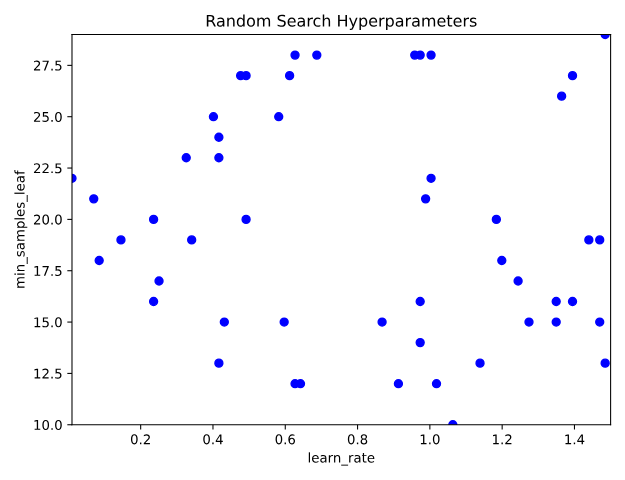


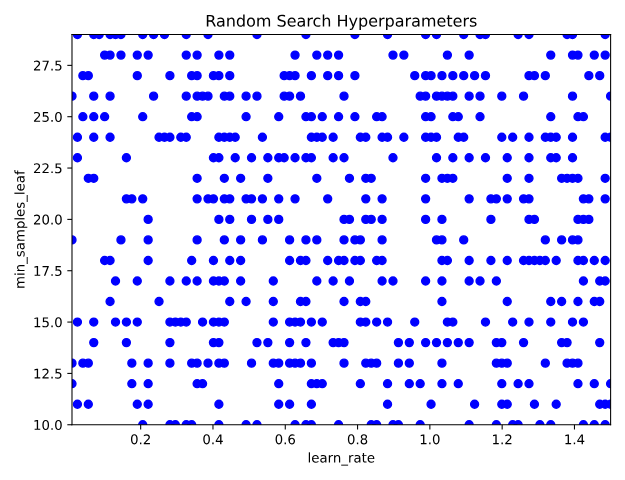

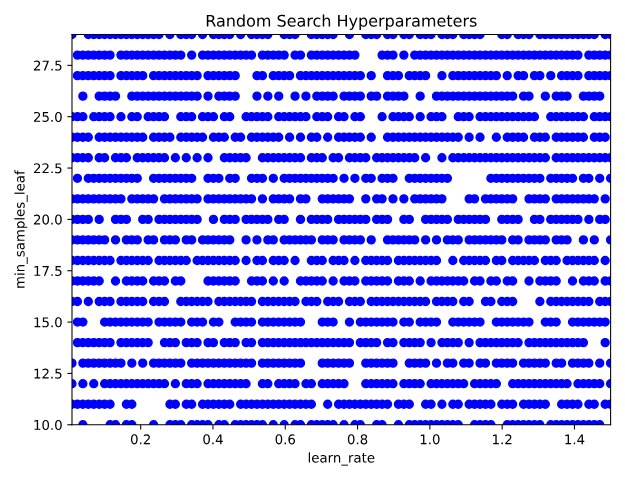

The RandomizedSearchCV Object
Just like the GridSearchCV library from Scikit Learn, RandomizedSearchCV provides many useful features to assist with efficiently undertaking a random search. You're going to create a RandomizedSearchCV object, making the small adjustment needed from the GridSearchCV object.

The desired options are:

A default Gradient Boosting Classifier Estimator
5-fold cross validation
Use accuracy to score the models
Use 4 cores for processing in parallel
Ensure you refit the best model and return training scores
Randomly sample 10 models
The hyperparameter grid should be for learning_rate (150 values between 0.1 and 2) and min_samples_leaf (all values between and including 20 and 64).

You will have available X_train & y_train datasets.

Create a parameter grid as specified in the context above.
Create a RandomizedSearchCV object as outlined in the context above.
Fit the RandomizedSearchCV object to the training data.
Print the values chosen by the modeling process for both hyperparameters.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

# Create the parameter grid
param_grid = {'learning_rate': np.linspace(0.1,2,150), 'min_samples_leaf': list(range(20,65))}

# Create a random search object
random_GBM_class = RandomizedSearchCV(
    estimator = GradientBoostingClassifier(),
    param_distributions = param_grid,
    n_iter = 10,
    scoring='accuracy', n_jobs=4, cv = 5, refit=True, return_train_score = True)

# Fit to the training data
random_GBM_class.fit(X_train, y_train)

# Print the values used for both hyperparameters
print(random_GBM_class.cv_results_['param_learning_rate'])
print(random_GBM_class.cv_results_['param_min_samples_leaf'])


<script.py> output:
[1.1073825503355705 1.0691275167785235 0.4697986577181208
 1.2476510067114095 1.5664429530201343 1.7577181208053692
 1.859731543624161 1.5791946308724834 0.5463087248322147
 1.7577181208053692]
[47 54 61 30 63 32 60 43 38 27]

RandomSearchCV in Scikit Learn

Let's practice building a RandomizedSearchCV object using Scikit Learn.

The hyperparameter grid should be for max_depth (all values between and including 5 and 25) and max_features ('auto' and 'sqrt').

The desired options for the RandomizedSearchCV object are:

A RandomForestClassifier Estimator with n_estimators of 80.
3-fold cross validation (cv)
Use roc_auc to score the models
Use 4 cores for processing in parallel (n_jobs)
Ensure you refit the best model and return training scores
Only sample 5 models for efficiency (n_iter)
X_train & y_train datasets are loaded for you.

Remember, to extract the chosen hyperparameters these are found in cv_results_ with a column per hyperparameter. For example, the column for the hyperparameter criterion would be param_criterion.

Create a hyperparameter grid as specified in the context above.
Create a RandomizedSearchCV object as outlined in the context above.
Fit the RandomizedSearchCV object to the training data.
Index into the cv_results_ object to print the values chosen by the modeling process for both hyperparameters (max_depth and max_features).

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create the parameter grid
param_grid = {'max_depth': list(range(5,26)), 'max_features': ['auto', 'sqrt']}

# Create a random search object
random_rf_class = RandomizedSearchCV(
    estimator = RandomForestClassifier (n_estimators=80),
    param_distributions = param_grid, n_iter = 5,
    scoring='roc_auc', n_jobs=4, cv = 3, refit=True, return_train_score = True )

# Fit to the training data
random_rf_class.fit(X_train, y_train)

# Print the values used for both hyperparameters
print(random_rf_class.cv_results_['param_max_depth'])
print(random_rf_class.cv_results_['param_max_features'])

<script.py> output:
    [18 11 10 22 10]
    ['sqrt' 'auto' 'sqrt' 'sqrt' 'auto']

Grid and Random Search Side by Side

Visualizing the search space of random and grid search together allows you to easily see the coverage that each technique has and therefore brings to life their specific advantages and disadvantages.

In this exercise, you will sample hyperparameter combinations in a grid search way as well as a random search way, then plot these to see the difference.

You will have available:

combinations_list which is a list of combinations of learn_rate and min_samples_leaf for this algorithm
The function visualize_search() which will make your hyperparameter combinations into X and Y coordinates and plot both grid and random search combinations on the same graph. It takes as input two lists of hyperparameter combinations.
If you wish to view the visualize_search() function definition, you can run this code:

import inspect
print(inspect.getsource(visualize_search))

Sample (by slicing) 300 hyperparameter combinations for a grid search from combinations_list into two lists and print the result.

In [ ]:
# Sample grid coordinates
grid_combinations_chosen =combinations_list[0:300]

# Print result
print(grid_combinations_chosen)

<script.py> output:
    [[0.01, 5], [0.01, 6], [0.01, 7], [0.01, 8], [0.01, 9], [0.01, 10], [0.01, 11], [0.01, 12], [0.01, 13], [0.01, 14], [0.01, 15], [0.01, 16], [0.01, 17], [0.01, 18], [0.01, 19], [0.01, 20], [0.01, 21], [0.01, 22], [0.01, 23], [0.01, 24], [0.025025125628140705, 5], [0.025025125628140705, 6], [0.025025125628140705, 7], [0.025025125628140705, 8], [0.025025125628140705, 9], [0.025025125628140705, 10], [0.025025125628140705, 11], [0.025025125628140705, 12], [0.025025125628140705, 13], [0.025025125628140705, 14], [0.025025125628140705, 15], [0.025025125628140705, 16], [0.025025125628140705, 17], [0.025025125628140705, 18], [0.025025125628140705, 19], [0.025025125628140705, 20], [0.025025125628140705, 21], [0.025025125628140705, 22], [0.025025125628140705, 23], [0.025025125628140705, 24], [0.04005025125628141, 5], [0.04005025125628141, 6], [0.04005025125628141, 7], [0.04005025125628141, 8], [0.04005025125628141, 9], [0.04005025125628141, 10], [0.04005025125628141, 11], [0.04005025125628141, 12], [0.04005025125628141, 13], [0.04005025125628141, 14], [0.04005025125628141, 15], [0.04005025125628141, 16], [0.04005025125628141, 17], [0.04005025125628141, 18], [0.04005025125628141, 19], [0.04005025125628141, 20], [0.04005025125628141, 21], [0.04005025125628141, 22], [0.04005025125628141, 23], [0.04005025125628141, 24], [0.055075376884422114, 5], [0.055075376884422114, 6], [0.055075376884422114, 7], [0.055075376884422114, 8], [0.055075376884422114, 9], [0.055075376884422114, 10], [0.055075376884422114, 11], [0.055075376884422114, 12], [0.055075376884422114, 13], [0.055075376884422114, 14], [0.055075376884422114, 15], [0.055075376884422114, 16], [0.055075376884422114, 17], [0.055075376884422114, 18], [0.055075376884422114, 19], [0.055075376884422114, 20], [0.055075376884422114, 21], [0.055075376884422114, 22], [0.055075376884422114, 23], [0.055075376884422114, 24], [0.07010050251256282, 5], [0.07010050251256282, 6], [0.07010050251256282, 7], [0.07010050251256282, 8], [0.07010050251256282, 9], [0.07010050251256282, 10], [0.07010050251256282, 11], [0.07010050251256282, 12], [0.07010050251256282, 13], [0.07010050251256282, 14], [0.07010050251256282, 15], [0.07010050251256282, 16], [0.07010050251256282, 17], [0.07010050251256282, 18], [0.07010050251256282, 19], [0.07010050251256282, 20], [0.07010050251256282, 21], [0.07010050251256282, 22], [0.07010050251256282, 23], [0.07010050251256282, 24], [0.08512562814070351, 5], [0.08512562814070351, 6], [0.08512562814070351, 7], [0.08512562814070351, 8], [0.08512562814070351, 9], [0.08512562814070351, 10], [0.08512562814070351, 11], [0.08512562814070351, 12], [0.08512562814070351, 13], [0.08512562814070351, 14], [0.08512562814070351, 15], [0.08512562814070351, 16], [0.08512562814070351, 17], [0.08512562814070351, 18], [0.08512562814070351, 19], [0.08512562814070351, 20], [0.08512562814070351, 21], [0.08512562814070351, 22], [0.08512562814070351, 23], [0.08512562814070351, 24], [0.10015075376884422, 5], [0.10015075376884422, 6], [0.10015075376884422, 7], [0.10015075376884422, 8], [0.10015075376884422, 9], [0.10015075376884422, 10], [0.10015075376884422, 11], [0.10015075376884422, 12], [0.10015075376884422, 13], [0.10015075376884422, 14], [0.10015075376884422, 15], [0.10015075376884422, 16], [0.10015075376884422, 17], [0.10015075376884422, 18], [0.10015075376884422, 19], [0.10015075376884422, 20], [0.10015075376884422, 21], [0.10015075376884422, 22], [0.10015075376884422, 23], [0.10015075376884422, 24], [0.11517587939698493, 5], [0.11517587939698493, 6], [0.11517587939698493, 7], [0.11517587939698493, 8], [0.11517587939698493, 9], [0.11517587939698493, 10], [0.11517587939698493, 11], [0.11517587939698493, 12], [0.11517587939698493, 13], [0.11517587939698493, 14], [0.11517587939698493, 15], [0.11517587939698493, 16], [0.11517587939698493, 17], [0.11517587939698493, 18], [0.11517587939698493, 19], [0.11517587939698493, 20], [0.11517587939698493, 21], [0.11517587939698493, 22], [0.11517587939698493, 23], [0.11517587939698493, 24], [0.13020100502512563, 5], [0.13020100502512563, 6], [0.13020100502512563, 7], [0.13020100502512563, 8], [0.13020100502512563, 9], [0.13020100502512563, 10], [0.13020100502512563, 11], [0.13020100502512563, 12], [0.13020100502512563, 13], [0.13020100502512563, 14], [0.13020100502512563, 15], [0.13020100502512563, 16], [0.13020100502512563, 17], [0.13020100502512563, 18], [0.13020100502512563, 19], [0.13020100502512563, 20], [0.13020100502512563, 21], [0.13020100502512563, 22], [0.13020100502512563, 23], [0.13020100502512563, 24], [0.14522613065326634, 5], [0.14522613065326634, 6], [0.14522613065326634, 7], [0.14522613065326634, 8], [0.14522613065326634, 9], [0.14522613065326634, 10], [0.14522613065326634, 11], [0.14522613065326634, 12], [0.14522613065326634, 13], [0.14522613065326634, 14], [0.14522613065326634, 15], [0.14522613065326634, 16], [0.14522613065326634, 17], [0.14522613065326634, 18], [0.14522613065326634, 19], [0.14522613065326634, 20], [0.14522613065326634, 21], [0.14522613065326634, 22], [0.14522613065326634, 23], [0.14522613065326634, 24], [0.16025125628140705, 5], [0.16025125628140705, 6], [0.16025125628140705, 7], [0.16025125628140705, 8], [0.16025125628140705, 9], [0.16025125628140705, 10], [0.16025125628140705, 11], [0.16025125628140705, 12], [0.16025125628140705, 13], [0.16025125628140705, 14], [0.16025125628140705, 15], [0.16025125628140705, 16], [0.16025125628140705, 17], [0.16025125628140705, 18], [0.16025125628140705, 19], [0.16025125628140705, 20], [0.16025125628140705, 21], [0.16025125628140705, 22], [0.16025125628140705, 23], [0.16025125628140705, 24], [0.17527638190954775, 5], [0.17527638190954775, 6], [0.17527638190954775, 7], [0.17527638190954775, 8], [0.17527638190954775, 9], [0.17527638190954775, 10], [0.17527638190954775, 11], [0.17527638190954775, 12], [0.17527638190954775, 13], [0.17527638190954775, 14], [0.17527638190954775, 15], [0.17527638190954775, 16], [0.17527638190954775, 17], [0.17527638190954775, 18], [0.17527638190954775, 19], [0.17527638190954775, 20], [0.17527638190954775, 21], [0.17527638190954775, 22], [0.17527638190954775, 23], [0.17527638190954775, 24], [0.19030150753768846, 5], [0.19030150753768846, 6], [0.19030150753768846, 7], [0.19030150753768846, 8], [0.19030150753768846, 9], [0.19030150753768846, 10], [0.19030150753768846, 11], [0.19030150753768846, 12], [0.19030150753768846, 13], [0.19030150753768846, 14], [0.19030150753768846, 15], [0.19030150753768846, 16], [0.19030150753768846, 17], [0.19030150753768846, 18], [0.19030150753768846, 19], [0.19030150753768846, 20], [0.19030150753768846, 21], [0.19030150753768846, 22], [0.19030150753768846, 23], [0.19030150753768846, 24], [0.20532663316582916, 5], [0.20532663316582916, 6], [0.20532663316582916, 7], [0.20532663316582916, 8], [0.20532663316582916, 9], [0.20532663316582916, 10], [0.20532663316582916, 11], [0.20532663316582916, 12], [0.20532663316582916, 13], [0.20532663316582916, 14], [0.20532663316582916, 15], [0.20532663316582916, 16], [0.20532663316582916, 17], [0.20532663316582916, 18], [0.20532663316582916, 19], [0.20532663316582916, 20], [0.20532663316582916, 21], [0.20532663316582916, 22], [0.20532663316582916, 23], [0.20532663316582916, 24], [0.22035175879396987, 5], [0.22035175879396987, 6], [0.22035175879396987, 7], [0.22035175879396987, 8], [0.22035175879396987, 9], [0.22035175879396987, 10], [0.22035175879396987, 11], [0.22035175879396987, 12], [0.22035175879396987, 13], [0.22035175879396987, 14], [0.22035175879396987, 15], [0.22035175879396987, 16], [0.22035175879396987, 17], [0.22035175879396987, 18], [0.22035175879396987, 19], [0.22035175879396987, 20], [0.22035175879396987, 21], [0.22035175879396987, 22], [0.22035175879396987, 23], [0.22035175879396987, 24]]

Let's randomly sample too. Create a list of every index in combinations_list to sample from using range()

Use np.random.choice() to sample 300 combinations. The first two arguments are a list to sample from and the number of samples.

Use the list of random indexes to index into combinations_list using a list comprehension.

Use the provided visualize_search() function to visualize the two sampling methodologies. The first argument is your grid combinations, the second argument is the random combinations you created.

In [ ]:
# Sample grid coordinates
grid_combinations_chosen = combinations_list[0:300]

# Create a list of sample indexes
sample_indexes = list(range(0,len(combinations_list)))

# Randomly sample 300 indexes
random_indexes = np.random.choice(sample_indexes, 300, replace=False)

# Use indexes to create random sample
random_combinations_chosen = [combinations_list[index] for index in random_indexes]

# Call the function to produce the visualization
visualize_search(grid_combinations_chosen, random_combinations_chosen)

<Output>

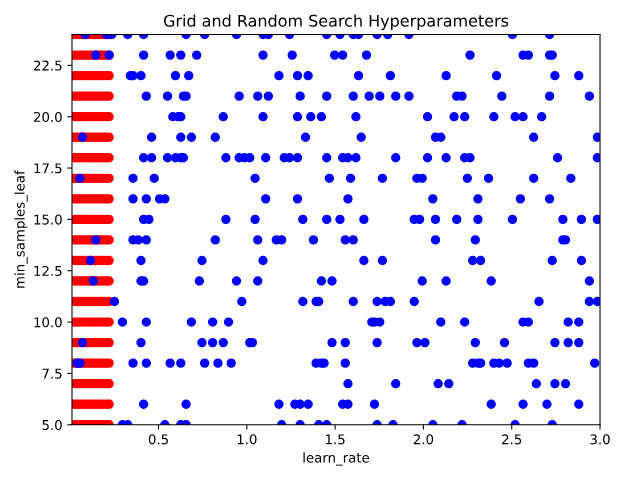

In [ ]:
Informed Search - Coarse to Fine

Visualizing Coarse to Fine
You're going to undertake the first part of a Coarse to Fine search. This involves analyzing the results of an initial random search that took place over a large search space, then deciding what would be the next logical step to make your hyperparameter search finer.

You have available:

combinations_list - a list of the possible hyperparameter combinations the random search was undertaken on.
results_df - a DataFrame that has each hyperparameter combination and the resulting accuracy of all 500 trials. Each hyperparameter is a column, with the header the hyperparameter name.
visualize_hyperparameter() - a function that takes in a column of the DataFrame (as a string) and produces a scatter plot of this column's values compared to the accuracy scores. An example call of the function would be visualize_hyperparameter('accuracy')
If you wish to view the visualize_hyperparameter() function definition, you can run this code:

import inspect
print(inspect.getsource(visualize_hyperparameter))

Instructions:

Confirm (by printing out) the size of the combinations_list, justifying the need to start with a random search.
Sort the results_df by accuracy values and print the top 10 rows. Are there clear insights? Beware a small sample size!
Confirm (by printing out) which hyperparameters were used in this search. These are the column names in results_df.
Call visualize_hyperparameter() with each hyperparameter in turn (max_depth, min_samples_leaf, learn_rate). Are there any trends?

In [ ]:
# Confirm the size of the combinations_list
print(len(combinations_list))

# Sort the results_df by accuracy and print the top 10 rows
print(results_df.sort_values(by='accuracy', ascending=False).head(10))

# Confirm which hyperparameters were used in this search
print(results_df.columns)

# Call visualize_hyperparameter() with each hyperparameter in turn
visualize_hyperparameter('max_depth')
visualize_hyperparameter('min_samples_leaf')
visualize_hyperparameter('learn_rate')

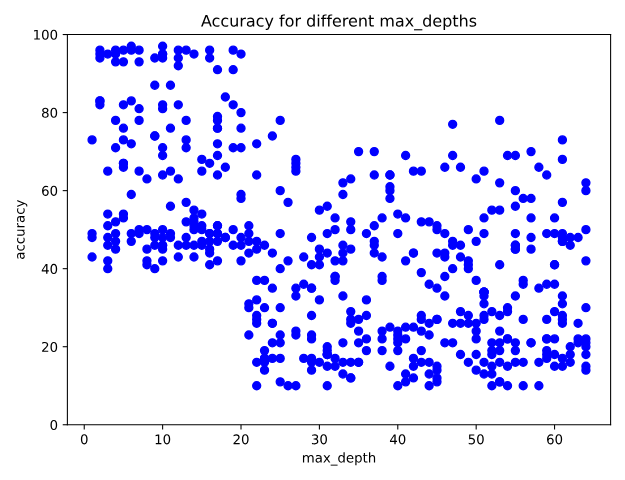

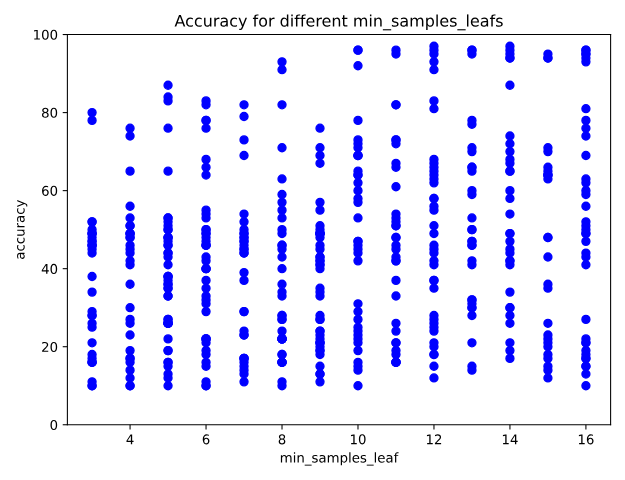



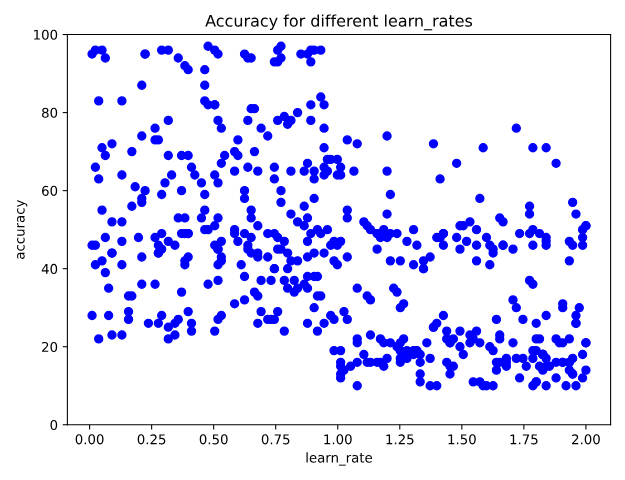

Coarse to Fine Iterations

You will now visualize the first random search undertaken, construct a tighter grid and check the results. You will have available:

results_df - a DataFrame that has the hyperparameter combination and the resulting accuracy of all 500 trials. Only the hyperparameters that had the strongest visualizations from the previous exercise are included (max_depth and learn_rate)
visualize_first() - This function takes no arguments but will visualize each of your hyperparameters against accuracy for your first random search.
If you wish to view the visualize_first() (or the visualize_second()) function definition, you can run this code:

import inspect
print(inspect.getsource(visualize_first))

Instructions:

Use the visualize_first() function to check the values of max_depth and learn_rate that tend to perform better. A convenient red line will be added to make this explicit.

Now create a more narrow grid search, testing for max_depth values between 1 and 20 and for 50 learning rates between 0.001 and 1.

We ran the 1,000 model grid search in the background based on those new combinations. Now use the visualize_second() function to visualize the second iteration (grid search) and see if there is any improved results. This function takes no arguments, just run it in-place to generate the plots!

In [ ]:
visualize_first()

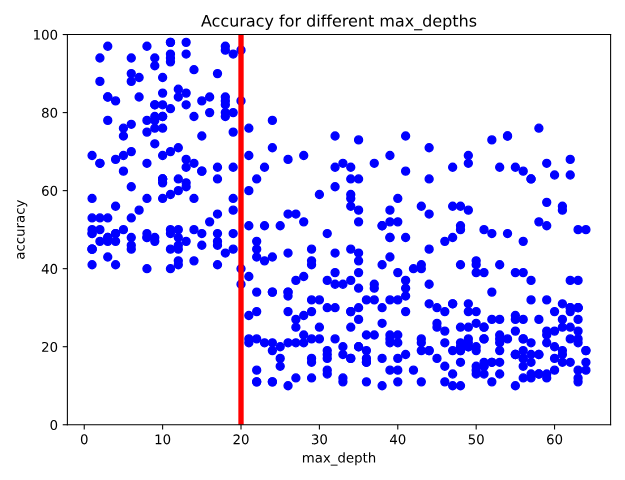

In [ ]:
# Use the provided function to visualize the first results
# visualize_first()

# Create some combinations lists & combine
max_depth_list = list(range(1, 21))
learn_rate_list = np.linspace(0.001, 1, 50)

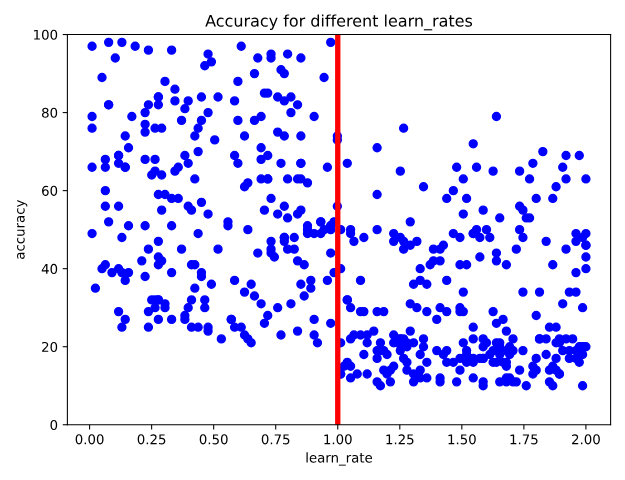

In [ ]:
# Use the provided function to visualize the first results
# visualize_first()

# Create some combinations lists & combine:
max_depth_list = list(range(1,21))
learn_rate_list = np.linspace(0.001,1,50)

# Call the function to visualize the second results
visualize_second()

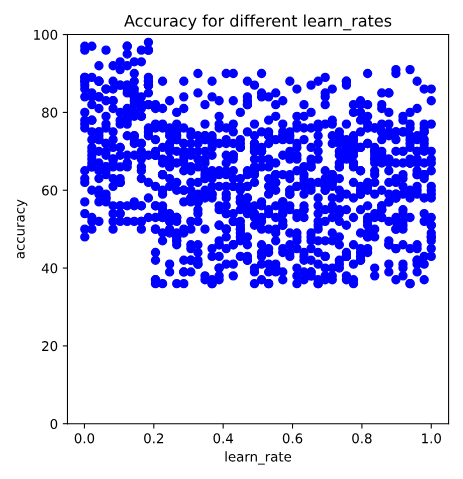

Informed Search - Bayesian Statistics

In this exercise you will undertake a practical example of setting up Bayes formula, obtaining new evidence and updating your 'beliefs' in order to get a more accurate result. The example will relate to the likelihood that someone will close their account for your online software product.

These are the probabilities we know:
7% (0.07) of people are likely to close their account next month
15% (0.15) of people with accounts are unhappy with your product (you don't know who though!)
35% (0.35) of people who are likely to close their account are unhappy with your product

Instructions:

Assign the different probabilities (as decimals) to variables. p_unhappy is the likelihood someone is unhappy, p_unhappy_close is the probability that someone is unhappy with the product, given they are going to close their account.

Assign the probability that someone will close their account next month to the variable p_close as a decimal.

You interview one of your customers and discover they are unhappy. What is the probability they will close their account, now that you know this evidence? Assign the result to p_close_unhappy and print it.

In [ ]:
# Assign probabilities to variables
p_unhappy = 0.15
p_unhappy_close = 0.35

# Probabiliy someone will close
p_close = 0.07

# Probability unhappy person will close
p_close_unhappy = (p_unhappy_close * p_close) / p_unhappy
print(p_close_unhappy)

<script.py> output:
    0.16333333333333336

Bayesian Hyperparameter tuning with Hyperopt

In this example you will set up and run a Bayesian hyperparameter optimization process using the package Hyperopt (already imported as hp for you). You will set up the domain (which is similar to setting up the grid for a grid search), then set up the objective function. Finally, you will run the optimizer over 20 iterations.

You will need to set up the domain using values:

max_depth using quniform distribution (between 2 and 10, increasing by 2)
learning_rate using uniform distribution (0.001 to 0.9)
Note that for the purpose of this exercise, this process was reduced in data sample size and hyperopt & GBM iterations. If you are trying out this method by yourself on your own machine, try a larger search space, more trials, more cvs and a larger dataset size to really see this in action!

Instructions
Set up a space dictionary using the domain mentioned above.
Set up the objective function using a gradient boosting classifier.
Run the algorithm for 20 evaluations (just use the default, suggested algorithm from the slides).

In [ ]:
# Set up space dictionary with specified hyperparameters
space = {'max_depth': hp.quniform('max_depth', 2, 10, 2),
         'learning_rate': hp.uniform('learning_rate', 0.001, 0.9)}

# Set up objective function
def objective(params):
    params = {'max_depth': int(params['max_depth']),'learning_rate': params['learning_rate']}
    gbm_clf = GradientBoostingClassifier(n_estimators=100, **params)
    best_score = cross_val_score(gbm_clf, X_train, y_train, scoring='accuracy', cv=2, n_jobs=4).mean()
    loss = 1 - best_score
    return loss

# Run the algorithm
best = fmin(fn=objective ,space=space, max_evals=20, rstate=np.random.default_rng(42), algo=tpe.suggest)
print(best)

<script.py> output:

  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]
  5%|5         | 1/20 [00:00<00:06,  3.12trial/s, best loss: 0.2825]
 10%|#         | 2/20 [00:00<00:06,  2.88trial/s, best loss: 0.2775000000000001]
 15%|#5        | 3/20 [00:00<00:05,  3.35trial/s, best loss: 0.24249999999999994]
 20%|##        | 4/20 [00:01<00:05,  3.03trial/s, best loss: 0.24249999999999994]
 25%|##5       | 5/20 [00:01<00:05,  2.85trial/s, best loss: 0.24249999999999994]
 30%|###       | 6/20 [00:02<00:06,  2.33trial/s, best loss: 0.24249999999999994]
 35%|###5      | 7/20 [00:02<00:04,  2.74trial/s, best loss: 0.24249999999999994]
 40%|####      | 8/20 [00:02<00:03,  3.33trial/s, best loss: 0.24249999999999994]
 45%|####5     | 9/20 [00:02<00:03,  3.59trial/s, best loss: 0.24249999999999994]
 50%|#####     | 10/20 [00:03<00:02,  3.70trial/s, best loss: 0.24249999999999994]
 55%|#####5    | 11/20 [00:03<00:02,  4.27trial/s, best loss: 0.23249999999999993]
 60%|######    | 12/20 [00:03<00:01,  4.23trial/s, best loss: 0.23249999999999993]
 65%|######5   | 13/20 [00:03<00:01,  3.95trial/s, best loss: 0.23249999999999993]
 70%|#######   | 14/20 [00:03<00:01,  4.44trial/s, best loss: 0.23249999999999993]
 75%|#######5  | 15/20 [00:04<00:01,  4.16trial/s, best loss: 0.23249999999999993]
 80%|########  | 16/20 [00:04<00:00,  4.45trial/s, best loss: 0.23249999999999993]
 85%|########5 | 17/20 [00:04<00:00,  4.83trial/s, best loss: 0.23249999999999993]
 90%|######### | 18/20 [00:04<00:00,  4.50trial/s, best loss: 0.23249999999999993]
 95%|#########5| 19/20 [00:05<00:00,  4.15trial/s, best loss: 0.23249999999999993]
100%|##########| 20/20 [00:05<00:00,  4.03trial/s, best loss: 0.23249999999999993]
100%|##########| 20/20 [00:05<00:00,  3.68trial/s, best loss: 0.23249999999999993]
    {'learning_rate': 0.038093061276450534, 'max_depth': 2.0}

Informed Search - Genetic Hyperparameter Tuning with TPOT
You're going to undertake a simple example of genetic hyperparameter tuning. TPOT is a very powerful library that has a lot of features. You're just scratching the surface in this lesson, but you are highly encouraged to explore in your own time.

This is a very small example. In real life, TPOT is designed to be run for many hours to find the best model. You would have a much larger population and offspring size as well as hundreds more generations to find a good model.

You will create the estimator, fit the estimator to the training data and then score this on the test data.

For this example we wish to use:

3 generations
4 in the population size
3 offspring in each generation
accuracy for scoring
A random_state of 2 has been set for consistency of results.

Instructions

Assign the values outlined in the context to the inputs for tpot_clf.
Create the tpot_clf classifier with the correct inputs.
Fit the classifier to the training data (X_train & y_train are available in your workspace).
Use the fitted classifier to score on the test set (X_test & y_test are available in your workspace).

In [ ]:
# Assign the values outlined to the inputs
number_generations = 3
population_size = 4
offspring_size = 3
scoring_function = 'accuracy'

# Create the tpot classifier
tpot_clf = TPOTClassifier(generations=number_generations, population_size=population_size,
                          offspring_size=offspring_size, scoring=scoring_function,
                          verbosity=2, random_state=2, cv=2)

# Fit the classifier to the training data
tpot_clf.fit(X_train , y_train)

# Score on the test set
print(tpot_clf.score(X_test, y_test))


<script.py> output:

Optimization Progress:   0%|          | 0/13 [00:00<?, ?pipeline/s]
Optimization Progress:  31%|###       | 4/13 [00:00<00:00, 37.37pipeline/s]

    Generation 1 - Current best internal CV score: 0.8075000000000001

Optimization Progress:  54%|#####3    | 7/13 [00:00<00:00, 37.37pipeline/s]
Optimization Progress:  62%|######1   | 8/13 [00:02<00:02,  2.47pipeline/s]

    Generation 2 - Current best internal CV score: 0.8075000000000001

Optimization Progress:  77%|#######6  | 10/13 [00:02<00:01,  2.47pipeline/s]
Optimization Progress:  77%|#######6  | 10/13 [00:03<00:00,  3.09pipeline/s]
Optimization Progress: 100%|##########| 13/13 [00:03<00:00,  3.90pipeline/s]

    Generation 3 - Current best internal CV score: 0.8075000000000001

Optimization Progress: 100%|##########| 13/13 [00:03<00:00,  3.90pipeline/s]

    Best pipeline: DecisionTreeClassifier(input_matrix, criterion=gini, max_depth=1, min_samples_leaf=10, min_samples_split=9)
    0.77

Analysing TPOT's stability

You will now see the random nature of TPOT by constructing the classifier with different random states and seeing what model is found to be best by the algorithm. This assists to see that TPOT is quite unstable when not run for a reasonable amount of time.

Instructions

1.Create the TPOT classifier, fit to the data and score using a random_state of 42.
2.Now try using a random_state of 122. The numbers don't mean anything special, but should produce different results.
3.Finally try using the random_state of 99. See how there is a different result again?


Result

You can see that TPOT is quite unstable when only running with low generations, population size and offspring. The first model chosen was a Decision Tree, then a K-nearest Neighbor model and finally a Random Forest. Increasing the generations, population size and offspring and running this for a long time will assist to produce better models and more stable results.

In [ ]:
# Create the tpot classifier
tpot_clf = TPOTClassifier(generations=2, population_size=4, offspring_size=3, scoring='accuracy', cv=2,
                          verbosity=2, random_state=42)

# Fit the classifier to the training data
tpot_clf.fit(X_train, y_train)

# Score on the test set
print(tpot_clf.score(X_test, y_test))

<script.py> output:

Optimization Progress:   0%|          | 0/10 [00:00<?, ?pipeline/s]
Optimization Progress:  20%|##        | 2/10 [00:00<00:01,  7.84pipeline/s]
Optimization Progress:  30%|###       | 3/10 [00:00<00:01,  6.10pipeline/s]
Optimization Progress:  40%|####      | 4/10 [00:00<00:00,  6.85pipeline/s]
Optimization Progress:  50%|#####     | 5/10 [00:00<00:00,  5.31pipeline/s]

    Generation 1 - Current best internal CV score: 0.7775000000000001

Optimization Progress:  70%|#######   | 7/10 [00:00<00:00,  5.31pipeline/s]
Optimization Progress:  70%|#######   | 7/10 [00:01<00:00,  6.69pipeline/s]
Optimization Progress:  90%|######### | 9/10 [00:01<00:00,  7.22pipeline/s]

    Generation 2 - Current best internal CV score: 0.7775000000000001

Optimization Progress: 100%|##########| 10/10 [00:01<00:00,  7.22pipeline/s]

    Best pipeline: RandomForestClassifier(input_matrix, bootstrap=True, criterion=gini, max_features=0.2, min_samples_leaf=8, min_samples_split=4, n_estimators=100)
    0.73

In [ ]:
# Create the tpot classifier
tpot_clf = TPOTClassifier(generations=2, population_size=4, offspring_size=3, scoring='accuracy', cv=2,
                          verbosity=2, random_state=122)

# Fit the classifier to the training data
tpot_clf.fit(X_train, y_train)

# Score on the test set
print(tpot_clf.score(X_test, y_test))


<script.py> output:

Optimization Progress:   0%|          | 0/10 [00:00<?, ?pipeline/s]
Optimization Progress:  40%|####      | 4/10 [00:00<00:00, 28.33pipeline/s]
Optimization Progress:  70%|#######   | 7/10 [00:00<00:00, 14.61pipeline/s]

    Generation 1 - Current best internal CV score: 0.7825

Optimization Progress:  70%|#######   | 7/10 [00:00<00:00, 14.61pipeline/s]
Optimization Progress:  90%|######### | 9/10 [00:00<00:00, 15.02pipeline/s]

    Generation 2 - Current best internal CV score: 0.7825

Optimization Progress: 100%|##########| 10/10 [00:00<00:00, 15.02pipeline/s]

    Best pipeline: BernoulliNB(input_matrix, alpha=0.01, fit_prior=True)
    0.76

In [ ]:
# Create the tpot classifier
tpot_clf = TPOTClassifier(generations=2, population_size=4, offspring_size=3, scoring='accuracy', cv=2,
                          verbosity=2, random_state=99)

# Fit the classifier to the training data
tpot_clf.fit(X_train, y_train)

# Score on the test set
print(tpot_clf.score(X_test, y_test))


<script.py> output:

Optimization Progress:   0%|          | 0/10 [00:00<?, ?pipeline/s]
Optimization Progress:  40%|####      | 4/10 [00:00<00:00,  6.34pipeline/s]
Optimization Progress:  50%|#####     | 5/10 [00:01<00:01,  4.53pipeline/s]
Optimization Progress:  60%|######    | 6/10 [00:01<00:01,  3.03pipeline/s]

    Generation 1 - Current best internal CV score: 0.7825

Optimization Progress:  70%|#######   | 7/10 [00:01<00:00,  3.03pipeline/s]
Optimization Progress:  70%|#######   | 7/10 [00:01<00:01,  2.99pipeline/s]
Optimization Progress:  80%|########  | 8/10 [00:02<00:00,  2.45pipeline/s]
Optimization Progress: 100%|##########| 10/10 [00:02<00:00,  3.45pipeline/s]

    Generation 2 - Current best internal CV score: 0.7825

Optimization Progress: 100%|##########| 10/10 [00:02<00:00,  3.45pipeline/s]

    Best pipeline: BernoulliNB(input_matrix, alpha=0.001, fit_prior=True)
    0.76